Loading the Bank Churners data and taking a first look at dimensions and structure.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/BankChurners.csv')

Check how many rows and columns we have, then peek at the first few rows.

In [3]:
print(df.shape)
df.head()

(10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## Dataset Overview

Next we check column names, dtypes, missing values, and basic numeric stats to confirm structure and spot any issues before deeper analysis.

In [4]:
print(df.columns.tolist())

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


Column list confirms what we have in the dataset and how many features we're working with.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

Info() shows dtypes and non-null counts—quick way to see if anything looks off before digging in.

In [6]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

Missing values per column—need to know this before aggregations or modeling.

In [7]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


Numeric summary—gives a sense of scale, spread, and whether any values look unreasonable.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

## Customer Attrition Distribution

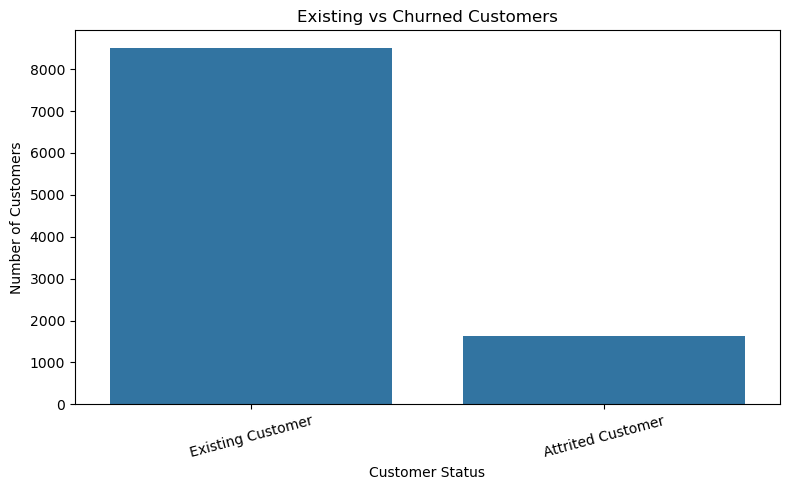

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition_Flag', order=df['Attrition_Flag'].value_counts().index)
plt.title('Existing vs Churned Customers')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The chart shows how many customers are still active vs churned. If churned is a small minority, we're looking at a class-imbalance situation for any predictive work; if it's a sizable share, the base rate is high enough to warrant focused retention analysis. Either way, knowing this split up front sets expectations for later modeling and for how we interpret segment-level churn rates.

## Income Category vs Customer Attrition

Income segmentation can reveal whether certain income groups are more likely to churn. If churn is concentrated in specific brackets, the bank can design targeted retention offers or communication; if it's spread evenly, income may be less useful for segmentation and other factors may matter more.

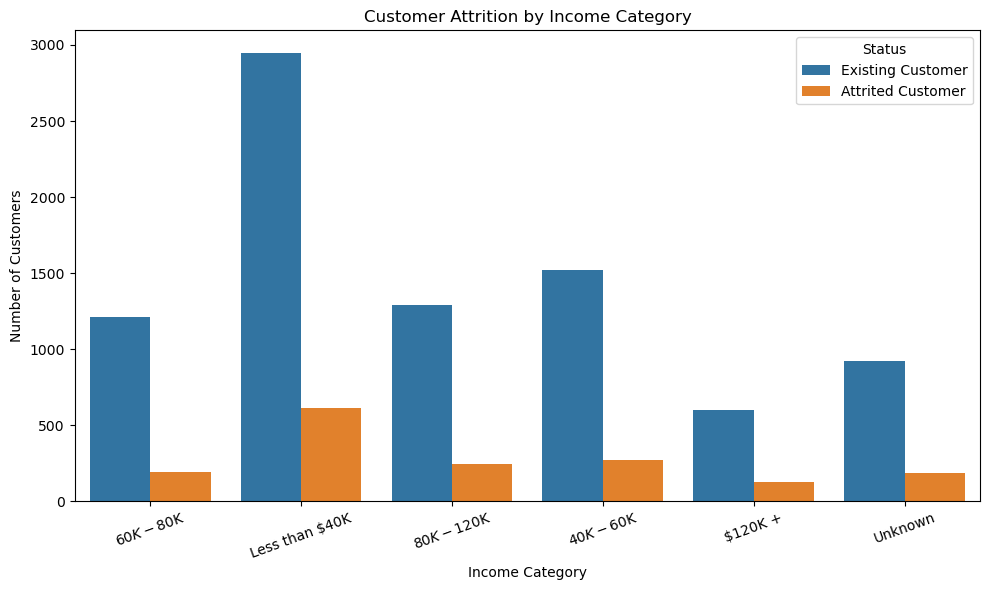

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag')
plt.title('Customer Attrition by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

From the stacked bars we can see whether churn is skewed toward low-income, high-income, or middle segments. If one or two categories stand out, income is a useful lever for retention programs (e.g. tailored offers by bracket). If the existing/churned ratio looks similar across income groups, income alone isn't a strong differentiator and we should look at other variables. Either way, this informs where to focus retention effort and whether income-based targeting is worth testing.

## Transaction Activity vs Customer Attrition

Customer engagement—e.g. number of transactions—reflects how actively people use their card. Lower activity often correlates with higher churn risk; comparing transaction levels between existing and churned customers shows whether that pattern holds here.

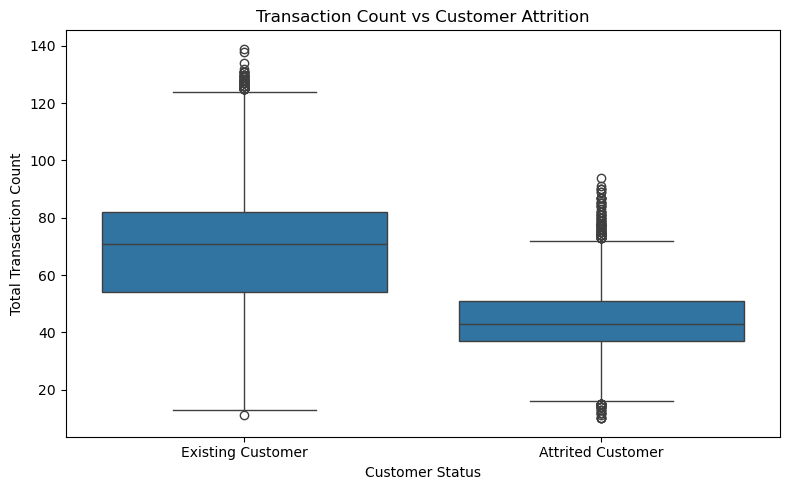

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct')
plt.title('Transaction Count vs Customer Attrition')
plt.xlabel('Customer Status')
plt.ylabel('Total Transaction Count')
plt.tight_layout()
plt.show()

If churned customers sit lower on the transaction-count scale than existing ones, activity is a plausible early-warning signal: declining use may precede attrition. Banks can use transaction frequency (or similar engagement metrics) to flag at-risk customers and trigger outreach before they leave.

## Feature Correlation Analysis

Before building predictive models or going deeper, it helps to look at correlations between numerical variables. That reveals which features move together and which might be useful (or redundant) when explaining churn.

/var/folders/vh/_4kqs_8x51g2bn492prm9pkr0000gn/T/ipykernel_57990/3293106386.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


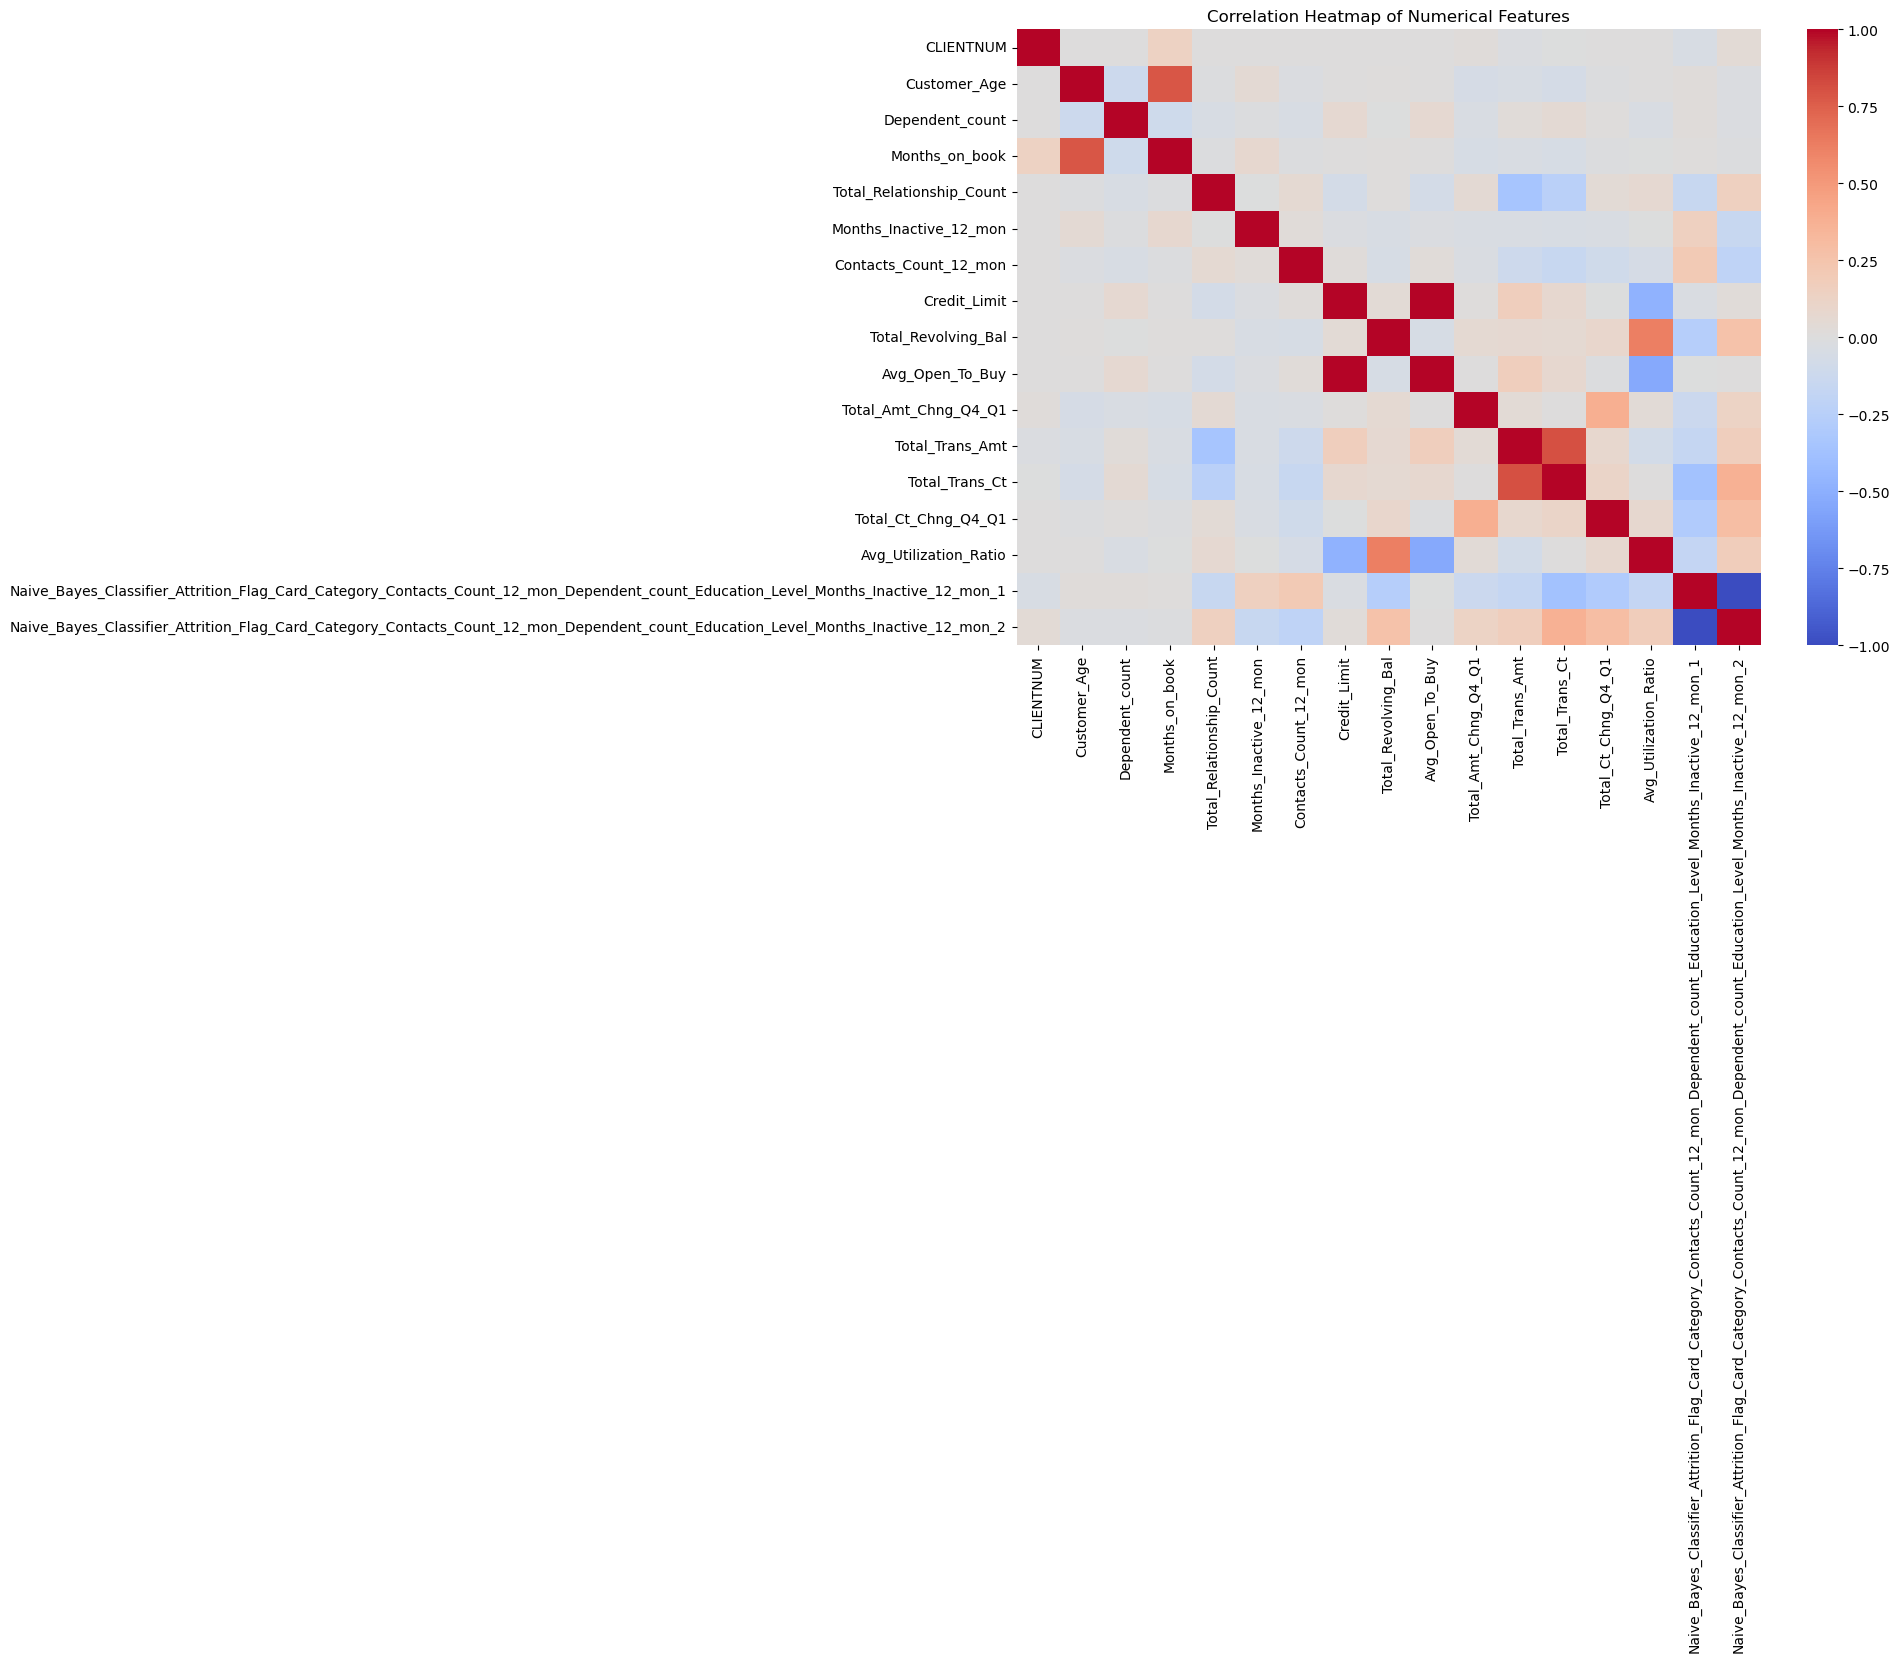

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

The heatmap shows where variables are positively or negatively related. Strong correlations can point to shared behavior (e.g. transaction counts and other activity metrics) or redundant info for modeling. Features like transaction activity, balances, and credit limits often cluster in ways that suggest which dimensions are worth digging into for churn.

## Card Category vs Customer Attrition

Banks offer different card tiers (e.g. Blue, Silver, Gold, Platinum). Comparing churn across these categories shows whether some products are losing customers more than others and where to focus retention.

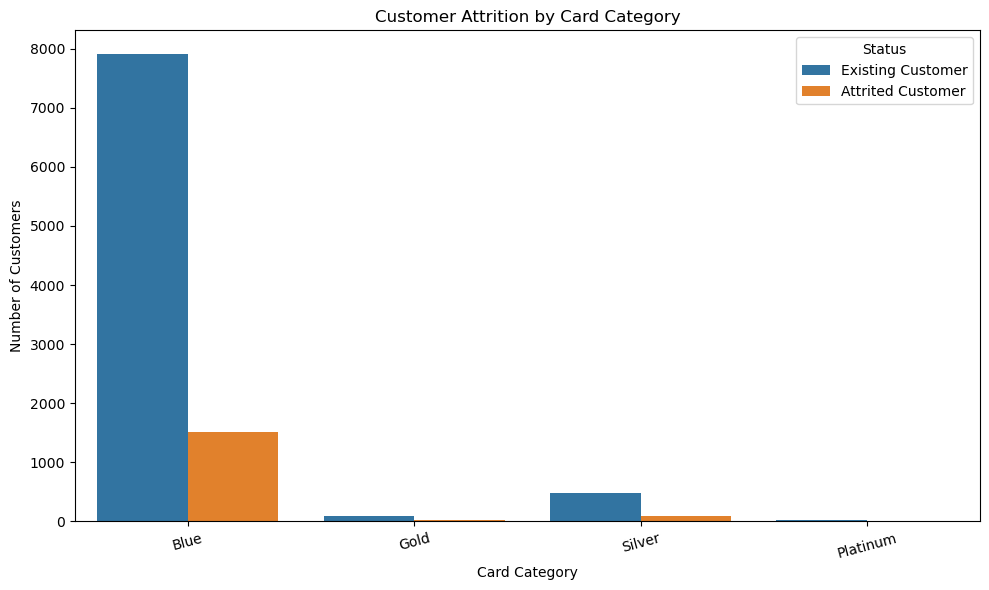

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Card_Category', hue='Attrition_Flag')
plt.title('Customer Attrition by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

If one or two card categories show a higher share of churned vs existing customers, that tier may need different retention tactics or product tweaks. If churn looks similar across tiers, the driver is likely broader than product type. Either way, product-level churn helps prioritize which segments get retention programs and how to tailor them.

## Customer Age Distribution vs Attrition

Demographics like age can shape how customers use financial products. Comparing the age distribution of churned vs retained customers shows whether certain age bands need different engagement or retention approaches.

/var/folders/vh/_4kqs_8x51g2bn492prm9pkr0000gn/T/ipykernel_57990/1310429904.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Status')


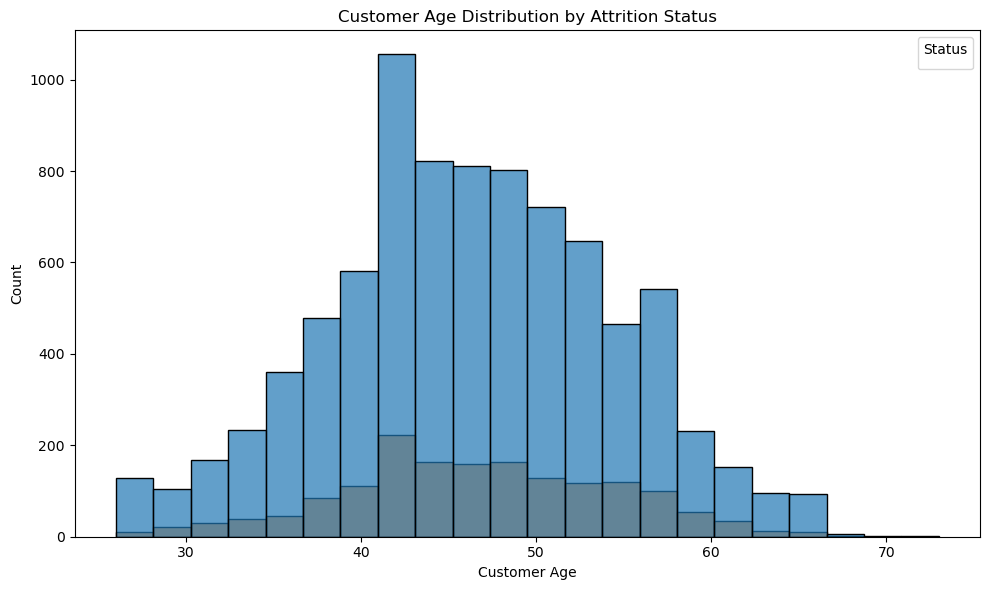

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', bins=22, multiple='layer', alpha=0.7)
plt.title('Customer Age Distribution by Attrition Status')
plt.xlabel('Customer Age')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

If churned customers concentrate in particular age ranges, age is a useful lever for segmentation and outreach. If the two groups look similar across ages, demographics alone may not explain churn and we’d look elsewhere. Either way, the comparison informs whether age-based retention tactics are worth testing.

## Key Business Insights

Based on the exploratory analysis and visualizations above, several patterns emerge that help explain customer churn behavior.

1. **Attrition distribution**
   The dataset shows that churned customers represent a smaller but significant portion of the customer base. This imbalance suggests the need for churn prediction models that account for class imbalance.

2. **Credit card usage and churn**
   Customers with lower transaction activity and lower credit usage appear more likely to churn. This suggests engagement with the card plays an important role in retention.

3. **Customer tenure**
   Customers with shorter tenure tend to churn more often than long-term customers, indicating that early lifecycle engagement strategies may reduce churn.

4. **Customer demographics**
   Certain demographic groups show higher churn tendencies, which may indicate differences in product satisfaction or engagement.

Overall, these insights suggest that **customer engagement and early lifecycle experience are key drivers of retention.**

## Business Recommendations

Based on the patterns identified in this analysis, the following strategies may help reduce customer churn:

**1. Early customer engagement programs**
Target customers in their first year with onboarding campaigns and incentives to increase card usage.

**2. Low-activity customer alerts**
Identify customers with declining transaction activity and trigger retention campaigns such as rewards or cashback offers.

**3. Personalized marketing**
Use behavioral data such as spending patterns and credit usage to offer tailored financial products.

**4. Churn prediction models**
Develop machine learning models to identify customers at risk of churn and proactively intervene.

Implementing these strategies could improve customer retention and increase long-term customer value.